# Archetypal Analysis Full Analysis Pipeline

This notebook reproduces the analysis from our report across three models:
- **Linear AA** : closed-form alternating least-squares solver
- **AAnet**: neural autoencoder with simplex-constrained latent space
- **MIDAA**: variational probabilistic archetypal analysis

**Datasets:** MNIST, BloodMNIST, Paul15 (scRNA-seq)

**Workflow:**
1. Linear AA k-sweep: select best k (MNIST=10, Blood=8, Paul15=11)
2. All three models trained with selected k, repeated R=5 times for consistency analysis
3. Analysis: loss/ELBO, NMI stability, consistency, archetypes, latent space, reconstructions
The other python files in here were used to generate the solution files.

All output figures can be found in the folder `results/figures`.
Note that for both AAnet and MIDAA a dedicated virtual environment is recommended
(see `requirements_midaa.txt` in this folder).

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from utils import calcNMI, plot_loss_arc, plot_nmi_stability

%matplotlib inline
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

colors  = ['#EF476F', '#06D6A0', '#FFD166', '#073B4C', '#118AB2', '#FF6B6B', '#C8A2C8']
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
SAVEDIR = 'results/figures'
os.makedirs(SAVEDIR, exist_ok=True)
print(f'device: {DEVICE}')

device: cpu


In [2]:
def plot_gene_heatmap(archetypes, gene_names, model_name, dataset_name, top_n=5, savedir=None):
    k = archetypes.shape[1]
    top_idx = sorted({i for col in range(k) for i in np.argsort(archetypes[:, col])[-top_n:]})
    data    = archetypes[top_idx, :]
    ylabels = [gene_names[i] for i in top_idx]
    fig, ax = plt.subplots(figsize=(k + 1, len(top_idx) * 0.4 + 1.5), layout='constrained')
    sns.heatmap(data, ax=ax, yticklabels=ylabels,
                xticklabels=[f'Arc {i+1}' for i in range(k)],
                cmap='YlOrRd', linewidths=0.2)
    ax.set_title(f'{model_name} â€“ {dataset_name} â€“ top {top_n} genes/archetype', fontsize=13)
    if savedir:
        tag = f'{model_name.lower().replace(" ", "_")}_{dataset_name.lower()}'
        plt.savefig(os.path.join(savedir, f'{tag}_archetype_gene_heatmap.png'),
                    dpi=150, bbox_inches='tight')
    plt.show()


def plot_mixing_weights(S, labels, label_names, model_name, dataset_name, savedir=None):
    # S: (k, n), labels: (n,) int
    k      = S.shape[0]
    unique = sorted(np.unique(labels))
    l2name = {l: label_names[labels == l][0] for l in unique}
    means  = np.array([S[:, labels == l].mean(axis=1) for l in unique])
    ynames = [l2name[l] for l in unique]
    palette = plt.cm.tab20(np.linspace(0, 1, k))
    fig, ax = plt.subplots(figsize=(max(8, k), max(4, len(unique) * 0.45 + 1.5)),
                           layout='constrained')
    bottom = np.zeros(len(unique))
    for i in range(k):
        ax.barh(ynames, means[:, i], left=bottom, color=palette[i], label=f'Arc {i+1}')
        bottom += means[:, i]
    ax.set_xlabel('Mean mixing weight', fontsize=12)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=8, loc='lower right', ncol=2)
    ax.set_title(f'{model_name} â€“ {dataset_name} â€“ mixing weights per cell type',
                 fontsize=13)
    if savedir:
        tag = f'{model_name.lower().replace(" ", "_")}_{dataset_name.lower()}'
        plt.savefig(os.path.join(savedir, f'{tag}_mixing_weights.png'),
                    dpi=150, bbox_inches='tight')
    plt.show()

In [3]:
def load_mnist_data(subset=1.0):
    import torchvision
    mnist = torchvision.datasets.MNIST(root='./data', train=True, download=True)
    X = (mnist.data.numpy().astype(np.float32) / 255.0).reshape(-1, 784)
    y = mnist.targets.numpy().astype(int)
    if subset < 1.0:
        rng = np.random.default_rng(42)
        idx = np.hstack([rng.choice(np.where(y == d)[0],
                         max(1, int(subset * np.sum(y == d))), replace=False)
                         for d in np.unique(y)])
        X, y = X[idx], y[idx]
    return X, y, y.astype(str)


def load_blood_data(subset=1.0):
    from medmnist import BloodMNIST
    blood = BloodMNIST(split='train', download=True, size=28)
    X = blood.imgs.reshape(len(blood.imgs), -1).astype(np.float32) / 255.0
    y = blood.labels.squeeze().astype(int)
    if subset < 1.0:
        rng = np.random.default_rng(42)
        idx = np.hstack([rng.choice(np.where(y == d)[0],
                         max(1, int(subset * np.sum(y == d))), replace=False)
                         for d in np.unique(y)])
        X, y = X[idx], y[idx]
    return X, y, y.astype(str)


def load_paul15_data():
    import scanpy as sc
    adata = sc.datasets.paul15()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=1000)
    adata = adata[:, adata.var['highly_variable']].copy()
    X = (adata.X if not hasattr(adata.X, 'toarray') else adata.X.toarray()).astype(np.float32)
    X_min, X_max = X.min(axis=0), X.max(axis=0)
    X = (X - X_min) / np.where(X_max - X_min > 0, X_max - X_min, 1.0)
    lnames = adata.obs['paul15_clusters'].astype(str).values
    unique = sorted(set(lnames))
    y = np.array([unique.index(l) for l in lnames], dtype=int)
    return X, y, lnames, adata.var_names.tolist()

In [4]:
print('Loading MNIST ...')
X_mnist, y_mnist, lnames_mnist = load_mnist_data(subset=1.0)
print(f'  {X_mnist.shape}')

print('Loading Blood ...')
X_blood, y_blood, lnames_blood = load_blood_data(subset=1.0)
print(f'  {X_blood.shape}')

print('Loading Paul15 ...')
X_paul, y_paul, lnames_paul, gene_names_paul = load_paul15_data()
print(f'  {X_paul.shape}')

Loading MNIST ...


  (60000, 784)
Loading Blood ...
  (11959, 2352)
Loading Paul15 ...
  (2730, 1000)


---
## Part 1: Linear Archetypal Analysis

We ran the AALS solver for k âˆˆ {6, â€¦, 16} with 4 repeated runs each. Based on the loss
and NMI stability curves we chose:
- **MNIST**: k = 10
- **BloodMNIST**: k = 8
- **Paul15**: k = 11

Consistency runs (R = 5) were executed on the HPC cluster. Results are loaded from `.pt` files.

In [20]:
r_laa_mnist  = torch.load('results/linear_aa_mnist_results.pt',  map_location='cpu', weights_only=False)
r_laa_blood  = torch.load('results/linear_aa_blood_results.pt',  map_location='cpu', weights_only=False)
r_laa_paul15 = torch.load('results/linear_aa_paul15_results.pt', map_location='cpu', weights_only=False)

print(f'{"Dataset":10s}  {"k":>4s}  {"Consistency":>12s}  {"ISI":>8s}')
print('-' * 40)
for name, r in [('MNIST', r_laa_mnist), ('Blood', r_laa_blood), ('Paul15', r_laa_paul15)]:
    k    = r['n_arc_consistency']
    R    = r['R']
    triu = np.triu_indices(R, k=1)
    cm   = np.array(r['consistency_matrix'])
    im   = np.array(r['ISI_matrix'])
    print(f'{name:10s}  {k:4d}  {cm[triu].mean():12.4f}  {im[triu].mean():8.4f}')

Dataset        k   Consistency       ISI
----------------------------------------
MNIST         10        0.9974    0.4267
Blood          8        0.9397    0.6406
Paul15        11        0.9461    0.6844


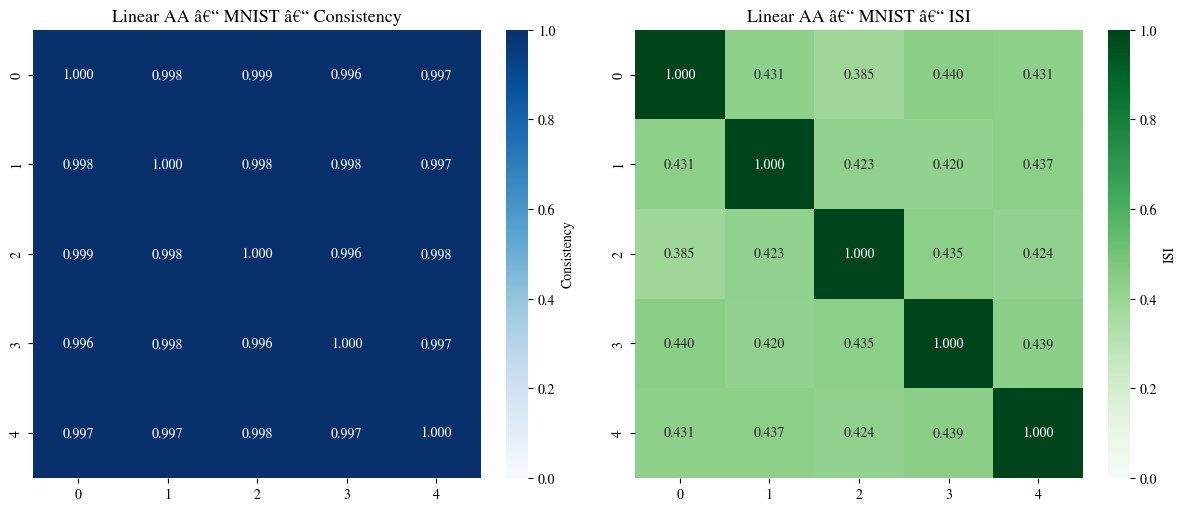

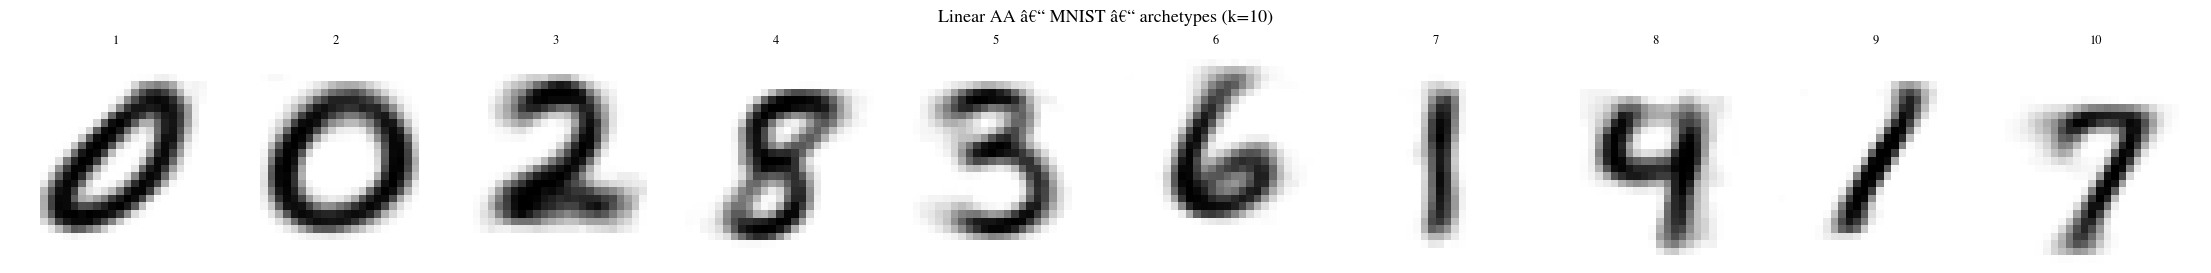

c:\DL_project\venv_midaa\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


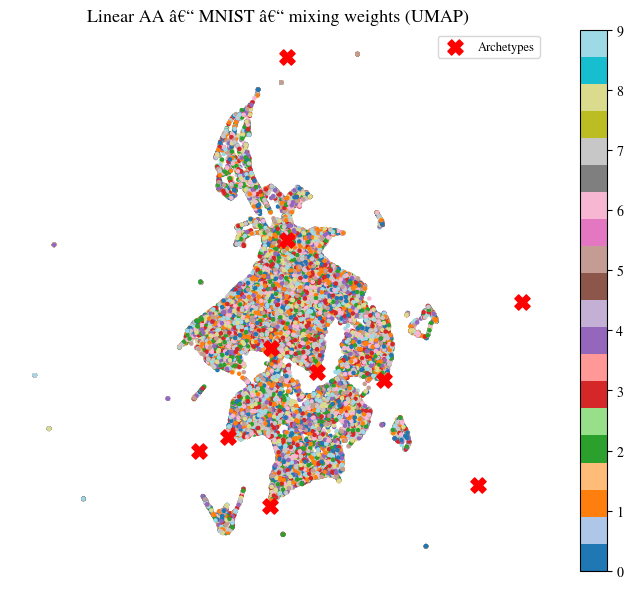

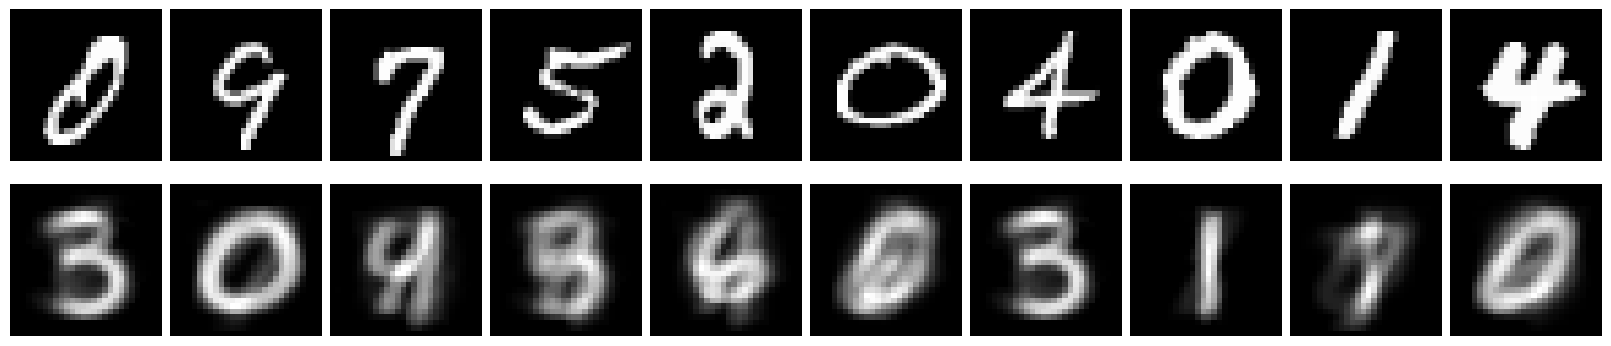

In [21]:
import umap as umap_lib

COLOR = colors[0]  # red/pink for Linear AA
r         = r_laa_mnist
k         = r['n_arc_consistency']
train_idx = r['train_idx']

plot_loss_arc(np.array(r['ValLosses']), r['n_arc_list'], 0, COLOR,
              'Linear AA', 'MNIST', savedir=SAVEDIR)
plot_nmi_stability(np.array(r['NMI']), r['n_arc_list'],
                   'Linear AA', 'MNIST', [COLOR], savedir=SAVEDIR)

cm     = np.array(r['consistency_matrix'])
im_mat = np.array(r['ISI_matrix'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
sns.heatmap(cm, ax=axes[0], annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'Consistency'})
axes[0].set_title('Linear AA â€“ MNIST â€“ Consistency', fontsize=13)
sns.heatmap(im_mat, ax=axes[1], annot=True, fmt='.3f', cmap='Greens', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'ISI'})
axes[1].set_title('Linear AA â€“ MNIST â€“ ISI', fontsize=13)
plt.show()

archetypes = np.array(r['archetype_list'][0])  # (784, k)
fig, axes = plt.subplots(1, k, figsize=(2.2 * k, 2.8), layout='constrained')
for i in range(k):
    axes[i].imshow(archetypes[:, i].reshape(28, 28), cmap='gray_r')
    axes[i].axis('off')
    axes[i].set_title(str(i + 1), fontsize=9)
fig.suptitle(f'Linear AA â€“ MNIST â€“ archetypes (k={k})', fontsize=13)
plt.show()

S        = r['Ss'][0][0].numpy()  # (k, n_train)
corners  = np.eye(k)
combined = np.vstack([S.T, corners])
emb_all  = umap_lib.UMAP(n_components=2, random_state=42).fit_transform(combined)
emb      = emb_all[:len(S.T)]
arc_pos  = emb_all[len(S.T):]
plt.figure(figsize=(7, 6))
sc = plt.scatter(emb[:, 0], emb[:, 1], s=5, c=y_mnist[train_idx], cmap='tab20')
plt.colorbar(sc)
plt.scatter(arc_pos[:, 0], arc_pos[:, 1], marker='X', c='red', s=120, zorder=5, label='Archetypes')
plt.legend(fontsize=9)
plt.axis('off')
plt.title('Linear AA â€“ MNIST â€“ mixing weights (UMAP)', fontsize=13)
plt.tight_layout()
plt.show()

recons = (archetypes @ S).T  # (n_train, 784)
n_show = 10
rng    = np.random.RandomState(42)
idx    = rng.choice(len(recons), n_show, replace=False)
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.6, 3.5), layout='constrained')
for j, i in enumerate(idx):
    axes[0, j].imshow(X_mnist[train_idx[i]].reshape(28, 28), cmap='gray')
    axes[1, j].imshow(np.clip(recons[i].reshape(28, 28), 0, 1), cmap='gray')
    axes[0, j].axis('off')
    axes[1, j].axis('off')
plt.show()


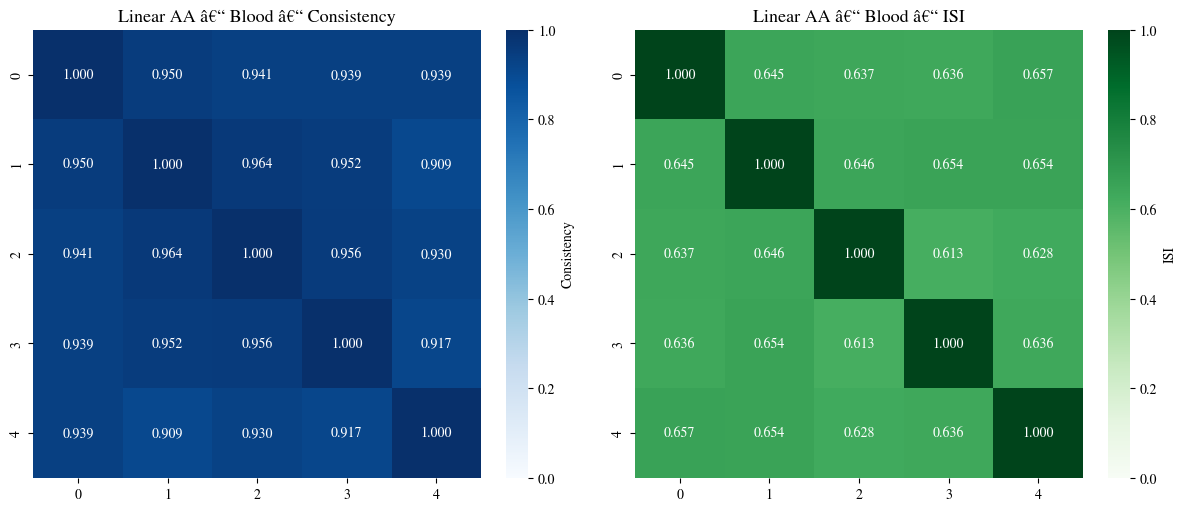

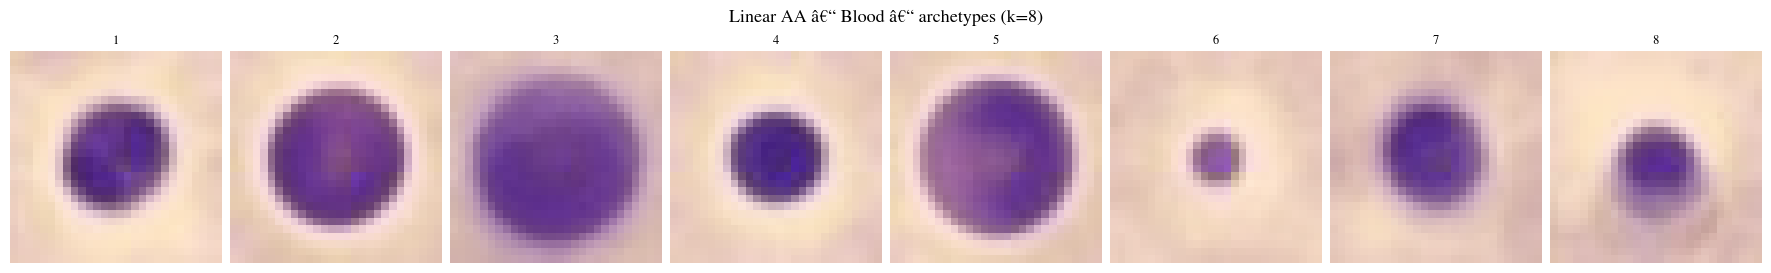

c:\DL_project\venv_midaa\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


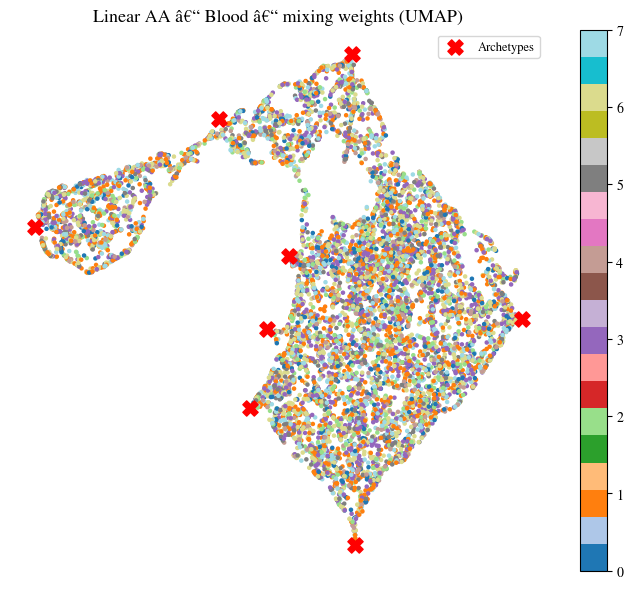

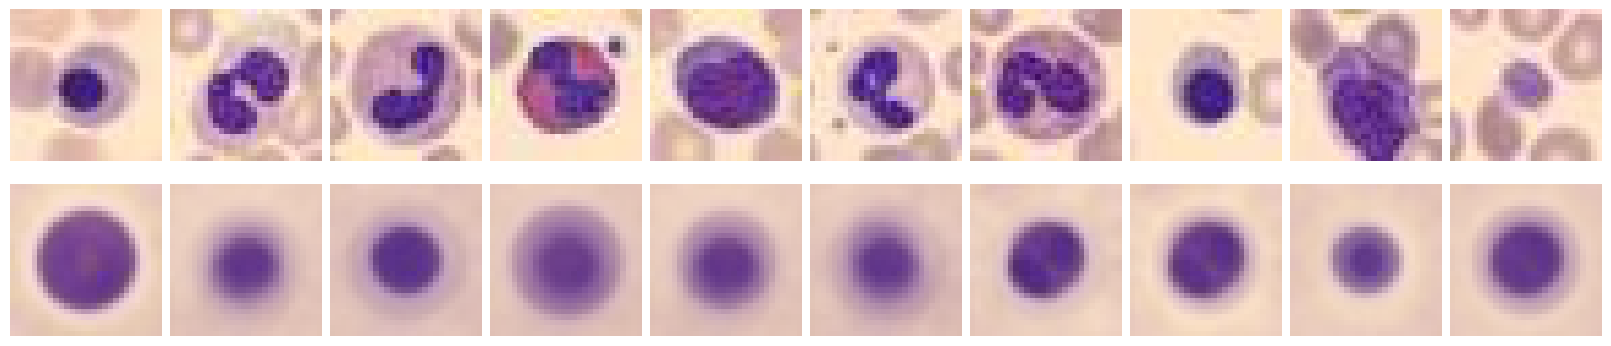

In [22]:
COLOR = colors[0]
r         = r_laa_blood
k         = r['n_arc_consistency']
train_idx = r['train_idx']

plot_loss_arc(np.array(r['ValLosses']), r['n_arc_list'], 1, COLOR,
              'Linear AA', 'Blood', savedir=SAVEDIR)
plot_nmi_stability(np.array(r['NMI']), r['n_arc_list'],
                   'Linear AA', 'Blood', [COLOR], savedir=SAVEDIR)

cm     = np.array(r['consistency_matrix'])
im_mat = np.array(r['ISI_matrix'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
sns.heatmap(cm, ax=axes[0], annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'Consistency'})
axes[0].set_title('Linear AA â€“ Blood â€“ Consistency', fontsize=13)
sns.heatmap(im_mat, ax=axes[1], annot=True, fmt='.3f', cmap='Greens', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'ISI'})
axes[1].set_title('Linear AA â€“ Blood â€“ ISI', fontsize=13)
plt.show()

archetypes = np.array(r['archetype_list'][0])  # (2352, k)
fig, axes = plt.subplots(1, k, figsize=(2.2 * k, 2.8), layout='constrained')
for i in range(k):
    axes[i].imshow(np.clip(archetypes[:, i].reshape(28, 28, 3), 0, 1))
    axes[i].axis('off')
    axes[i].set_title(str(i + 1), fontsize=9)
fig.suptitle(f'Linear AA â€“ Blood â€“ archetypes (k={k})', fontsize=13)
plt.show()

S        = r['Ss'][0][0].numpy()  # (k, n_train)
corners  = np.eye(k)
combined = np.vstack([S.T, corners])
emb_all  = umap_lib.UMAP(n_components=2, random_state=42).fit_transform(combined)
emb      = emb_all[:len(S.T)]
arc_pos  = emb_all[len(S.T):]
plt.figure(figsize=(7, 6))
sc = plt.scatter(emb[:, 0], emb[:, 1], s=5, c=y_blood[train_idx], cmap='tab20')
plt.colorbar(sc)
plt.scatter(arc_pos[:, 0], arc_pos[:, 1], marker='X', c='red', s=120, zorder=5, label='Archetypes')
plt.legend(fontsize=9)
plt.axis('off')
plt.title('Linear AA â€“ Blood â€“ mixing weights (UMAP)', fontsize=13)
plt.tight_layout()
plt.show()

recons = (archetypes @ S).T
n_show = 10
rng    = np.random.RandomState(42)
idx    = rng.choice(len(recons), n_show, replace=False)
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.6, 3.5), layout='constrained')
for j, i in enumerate(idx):
    axes[0, j].imshow(np.clip(X_blood[train_idx[i]].reshape(28, 28, 3), 0, 1))
    axes[1, j].imshow(np.clip(recons[i].reshape(28, 28, 3), 0, 1))
    axes[0, j].axis('off')
    axes[1, j].axis('off')
plt.show()


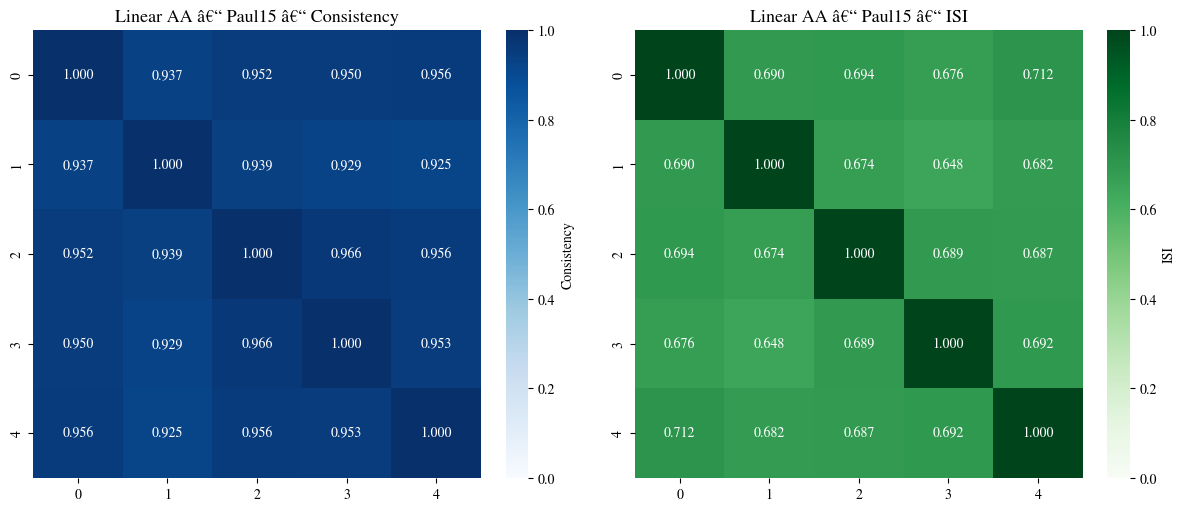

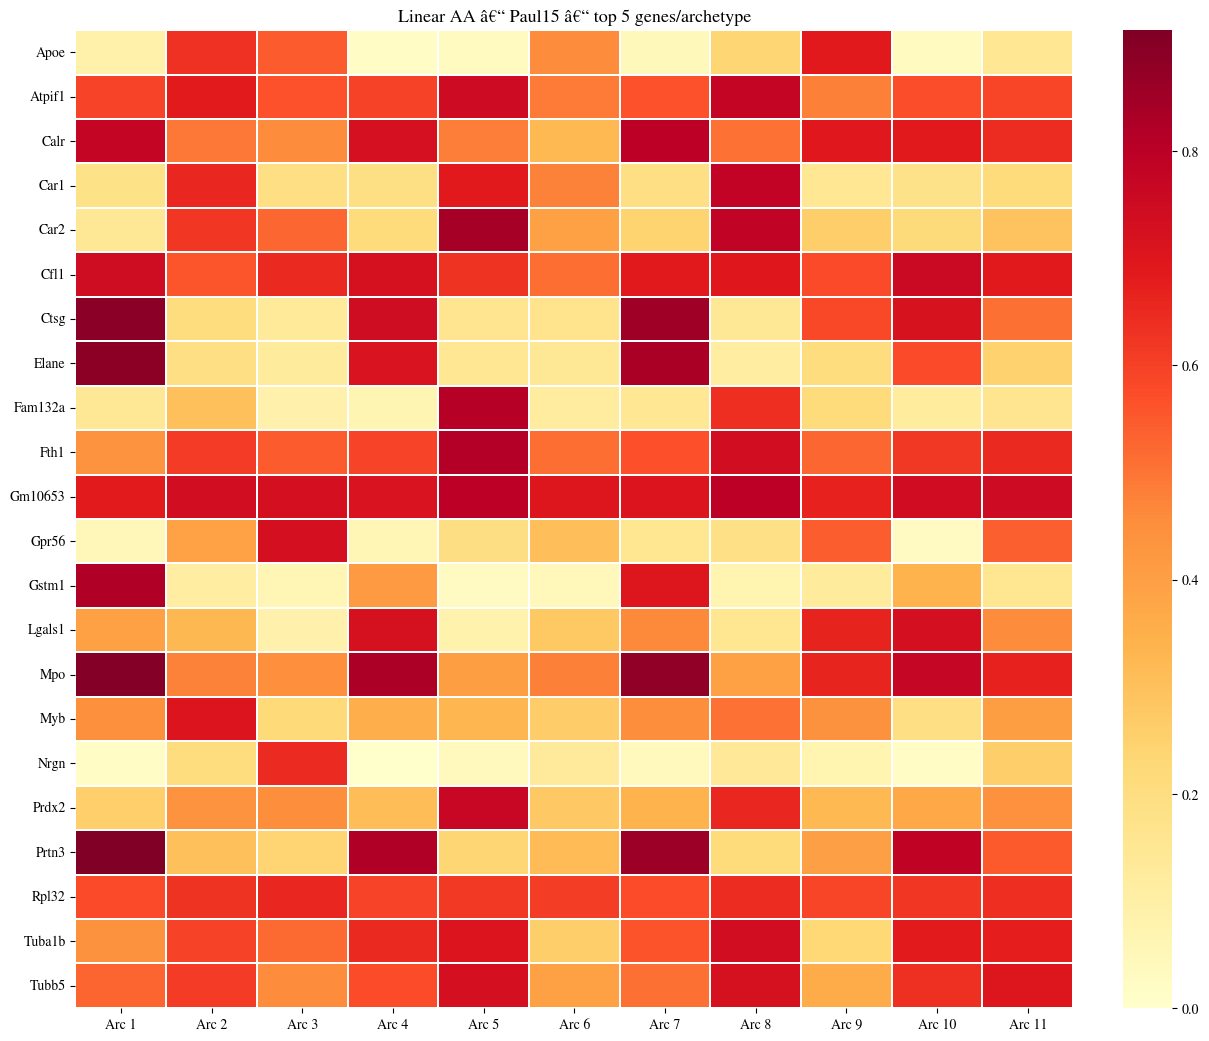

c:\DL_project\venv_midaa\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


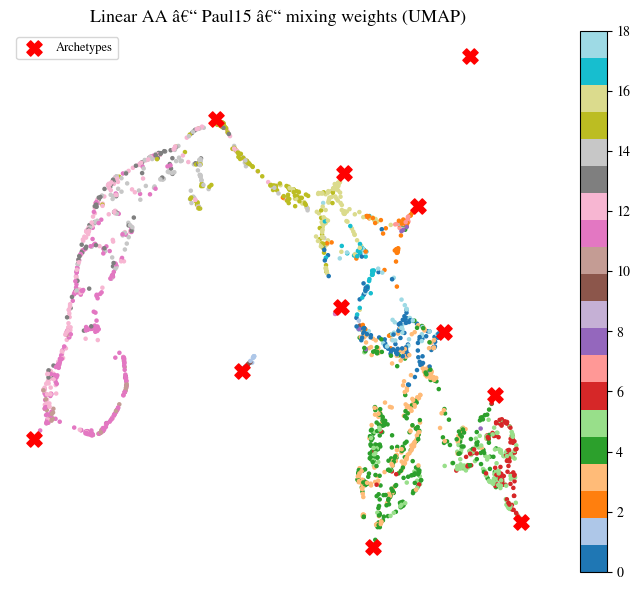

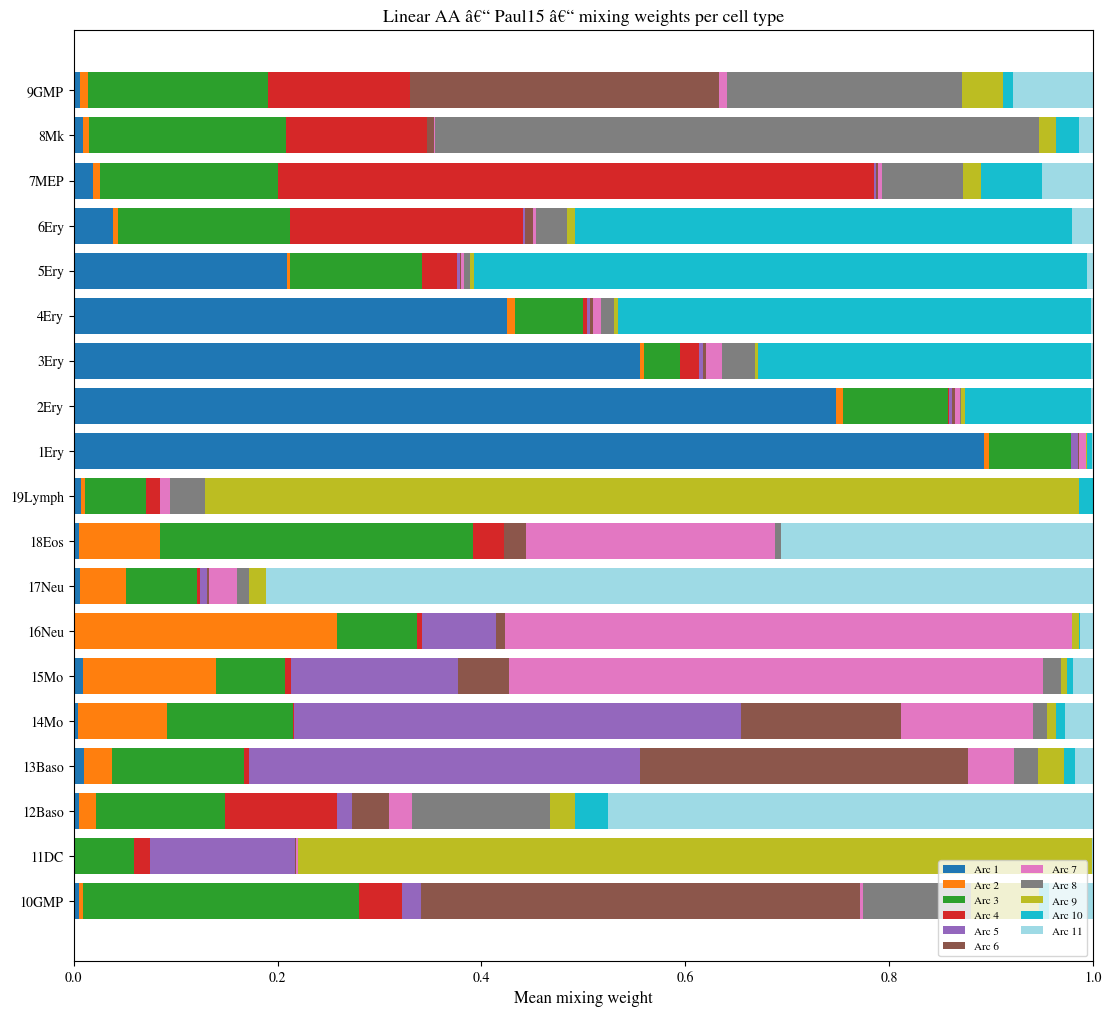

In [23]:
COLOR = colors[0]
r         = r_laa_paul15
k         = r['n_arc_consistency']
train_idx = r['train_idx']

plot_loss_arc(np.array(r['ValLosses']), r['n_arc_list'], 2, COLOR,
              'Linear AA', 'Paul15', savedir=SAVEDIR)
plot_nmi_stability(np.array(r['NMI']), r['n_arc_list'],
                   'Linear AA', 'Paul15', [COLOR], savedir=SAVEDIR)

cm     = np.array(r['consistency_matrix'])
im_mat = np.array(r['ISI_matrix'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
sns.heatmap(cm, ax=axes[0], annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'Consistency'})
axes[0].set_title('Linear AA â€“ Paul15 â€“ Consistency', fontsize=13)
sns.heatmap(im_mat, ax=axes[1], annot=True, fmt='.3f', cmap='Greens', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'ISI'})
axes[1].set_title('Linear AA â€“ Paul15 â€“ ISI', fontsize=13)
plt.show()

archetypes = np.array(r['archetype_list'][0])  # (n_genes, k)
plot_gene_heatmap(archetypes, r['gene_names'], 'Linear AA', 'Paul15', top_n=5, savedir=SAVEDIR)

S         = r['Ss'][0][0].numpy()  # (k, n_train)
ltr       = r['labels'][train_idx]
lnames_tr = r['label_names'][train_idx]
corners   = np.eye(k)
combined  = np.vstack([S.T, corners])
emb_all   = umap_lib.UMAP(n_components=2, random_state=42).fit_transform(combined)
emb       = emb_all[:len(S.T)]
arc_pos   = emb_all[len(S.T):]
plt.figure(figsize=(7, 6))
sc = plt.scatter(emb[:, 0], emb[:, 1], s=5, c=ltr, cmap='tab20')
plt.colorbar(sc)
plt.scatter(arc_pos[:, 0], arc_pos[:, 1], marker='X', c='red', s=120, zorder=5, label='Archetypes')
plt.legend(fontsize=9)
plt.axis('off')
plt.title('Linear AA â€“ Paul15 â€“ mixing weights (UMAP)', fontsize=13)
plt.tight_layout()
plt.show()

plot_mixing_weights(S, ltr, lnames_tr, 'Linear AA', 'Paul15', SAVEDIR)


---
## Part 2 â€” AAnet

AAnet uses a symmetric encoderâ€“decoder with a simplex-based archetypal loss in the latent
space. We ran 10 training runs per k and selected the best k based on NMI stability and
reconstruction loss.

Selected k: MNIST=10, Blood=8, Paul15=11.

> **Virtual environment required** â€” see `requirements_midaa.txt`.

In [11]:
# AAnet training reference (run on HPC)
#
# from aanetOrig import AAnet_vanilla, train_epoch
# from torch.utils.data import DataLoader, TensorDataset
#
# def train_aanet(X, k, epochs=200, lr=1e-3, layer_widths=[256, 128]):
#     model = AAnet_vanilla(input_shape=X.shape[1], n_archetypes=k,
#                            layer_widths=layer_widths)
#     opt   = torch.optim.Adam(model.parameters(), lr=lr)
#     X_t   = torch.tensor(X, dtype=torch.float32)
#     loader = DataLoader(TensorDataset(X_t), batch_size=256, shuffle=True)
#     for ep in range(epochs):
#         loss, _, _, _ = train_epoch(model, loader, opt, ep)
#     return model

r_aanet_mnist  = torch.load('results/aanet_mnist_results.pt',  map_location='cpu', weights_only=False)
r_aanet_blood  = torch.load('results/aanet_blood_results.pt',  map_location='cpu', weights_only=False)
r_aanet_paul15 = torch.load('results/aanet_paul15_results.pt', map_location='cpu', weights_only=False)

print(f'{"Dataset":10s}  {"k":>4s}  {"Rec. loss":>10s}  {"Consistency":>12s}  {"ISI":>8s}')
print('-' * 52)
for name, r in [('MNIST', r_aanet_mnist), ('Blood', r_aanet_blood), ('Paul15', r_aanet_paul15)]:
    k    = r['best_k']
    R    = len(r['consistency_matrix'])
    triu = np.triu_indices(R, k=1)
    cm   = np.array(r['consistency_matrix'])
    im   = np.array(r['ISI_matrix'])
    rec  = r['reconstruction_losses'][k]
    print(f'{name:10s}  {k:4d}  {rec:10.4f}  {cm[triu].mean():12.4f}  {im[triu].mean():8.4f}')

Dataset        k   Rec. loss   Consistency       ISI
----------------------------------------------------
MNIST         10      0.1296        0.1631    0.4936
Blood          8      0.0428        0.1066    0.5118
Paul15        11      0.1045        0.8083    0.8323


In [12]:
from aanetOrig import AAnet_vanilla

def run_aanet_inference(result, X):
    model = AAnet_vanilla(
        input_shape=result['input_shape'],
        n_archetypes=result['best_k'],
        layer_widths=result['layer_widths'],
    )
    model.load_state_dict(result['model_state_dicts'][-1])
    model.eval()
    z_parts, recon_parts = [], []
    X_t = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        for i in range(0, len(X_t), 512):
            recon, _, z = model(X_t[i:i + 512])
            z_parts.append(z.numpy())
            recon_parts.append(recon.numpy())
    return np.concatenate(z_parts), np.concatenate(recon_parts), model

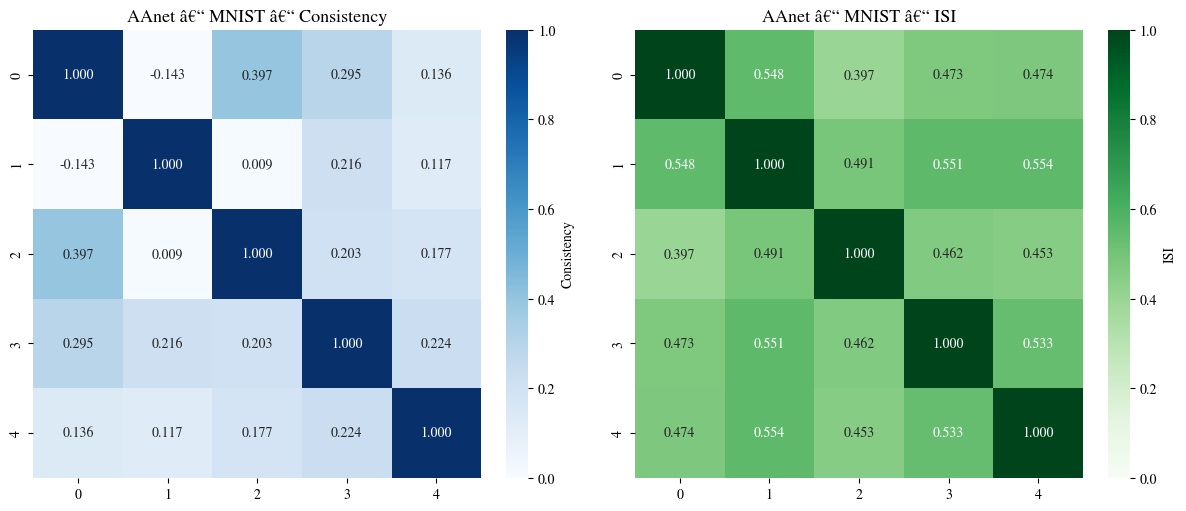

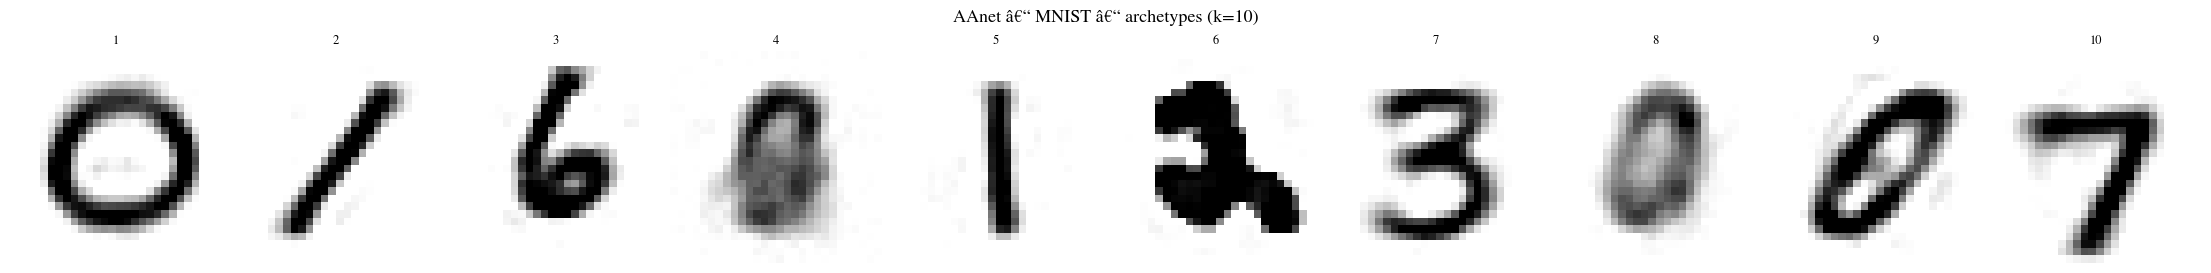

c:\DL_project\venv_aanet\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


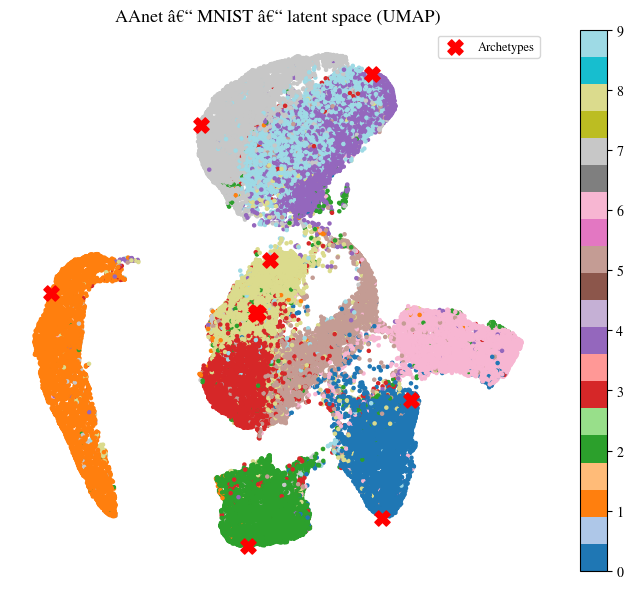

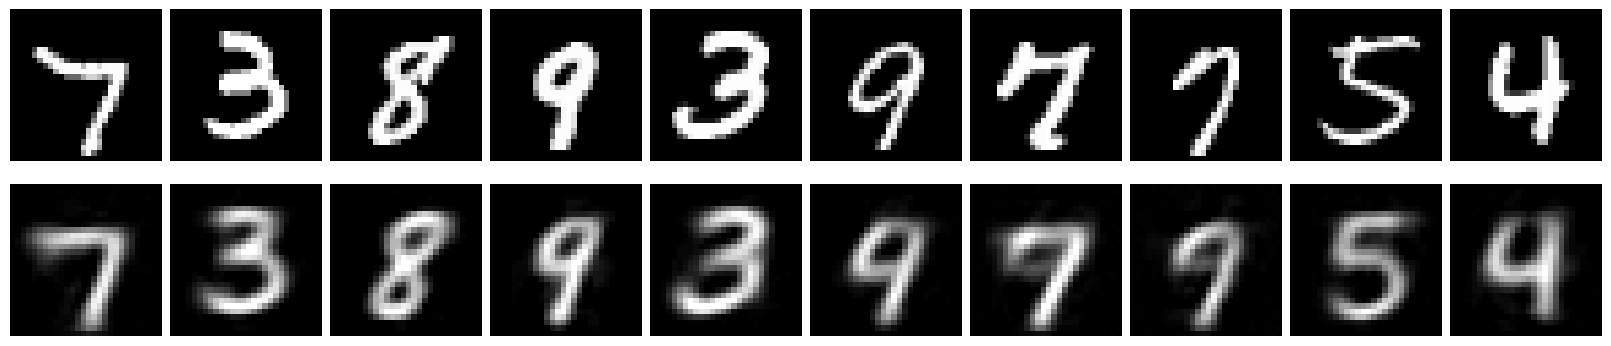

In [13]:
import umap as umap_lib
COLOR = colors[1]  # green for AAnet
r = r_aanet_mnist
k = r['best_k']

NMI_arr = np.array(r['NMI_results'][k]).reshape(1, -1)
plot_nmi_stability(NMI_arr, [k], 'AAnet', 'MNIST', [COLOR], savedir=SAVEDIR)

cm     = np.array(r['consistency_matrix'])
im_mat = np.array(r['ISI_matrix'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
sns.heatmap(cm, ax=axes[0], annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'Consistency'})
axes[0].set_title('AAnet â€“ MNIST â€“ Consistency', fontsize=13)
sns.heatmap(im_mat, ax=axes[1], annot=True, fmt='.3f', cmap='Greens', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'ISI'})
axes[1].set_title('AAnet â€“ MNIST â€“ ISI', fontsize=13)
plt.show()

archetypes = np.array(r['archetype_list'][0])  # (784, k), stored in [-1,1]
fig, axes = plt.subplots(1, k, figsize=(2.2 * k, 2.8), layout='constrained')
for i in range(k):
    axes[i].imshow(np.clip((archetypes[:, i].reshape(28, 28) + 1) / 2, 0, 1), cmap='gray_r')
    axes[i].axis('off')
    axes[i].set_title(str(i + 1), fontsize=9)
fig.suptitle(f'AAnet â€“ MNIST â€“ archetypes (k={k})', fontsize=13)
plt.show()

# AAnet operates in [-1, 1]; scale MNIST accordingly
X_scaled               = X_mnist * 2 - 1
z_all, recons, model_mnist = run_aanet_inference(r, X_scaled)
arc_pts  = model_mnist.archetypal_simplex.cpu().detach().numpy()
combined = np.vstack([z_all, arc_pts])
emb_all  = umap_lib.UMAP(n_components=2, random_state=42).fit_transform(combined)
emb      = emb_all[:len(z_all)]
arc_pos  = emb_all[len(z_all):]
plt.figure(figsize=(7, 6))
sc = plt.scatter(emb[:, 0], emb[:, 1], s=5, c=y_mnist, cmap='tab20')
plt.colorbar(sc)
plt.scatter(arc_pos[:, 0], arc_pos[:, 1], marker='X', c='red', s=120, zorder=5, label='Archetypes')
plt.legend(fontsize=9)
plt.axis('off')
plt.title('AAnet â€“ MNIST â€“ latent space (UMAP)', fontsize=13)
plt.tight_layout()
plt.show()

recons_01 = (recons + 1) / 2  # [-1,1] -> [0,1]
n_show = 10
rng    = np.random.RandomState(42)
idx    = rng.choice(len(recons_01), n_show, replace=False)
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.6, 3.5), layout='constrained')
for j, i in enumerate(idx):
    axes[0, j].imshow(X_mnist[i].reshape(28, 28), cmap='gray')
    axes[1, j].imshow(np.clip(recons_01[i].reshape(28, 28), 0, 1), cmap='gray')
    axes[0, j].axis('off')
    axes[1, j].axis('off')
plt.show()


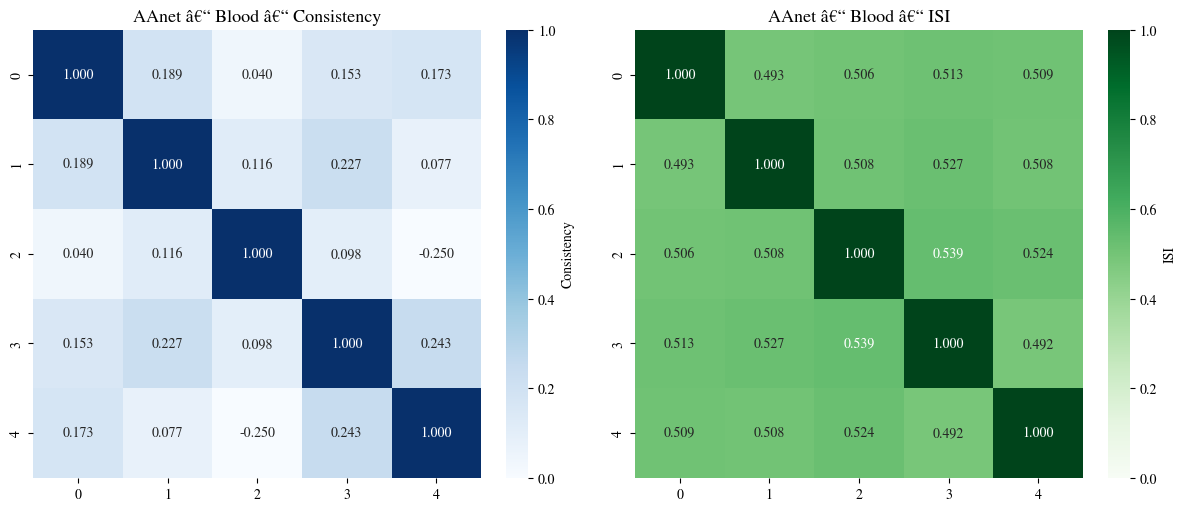

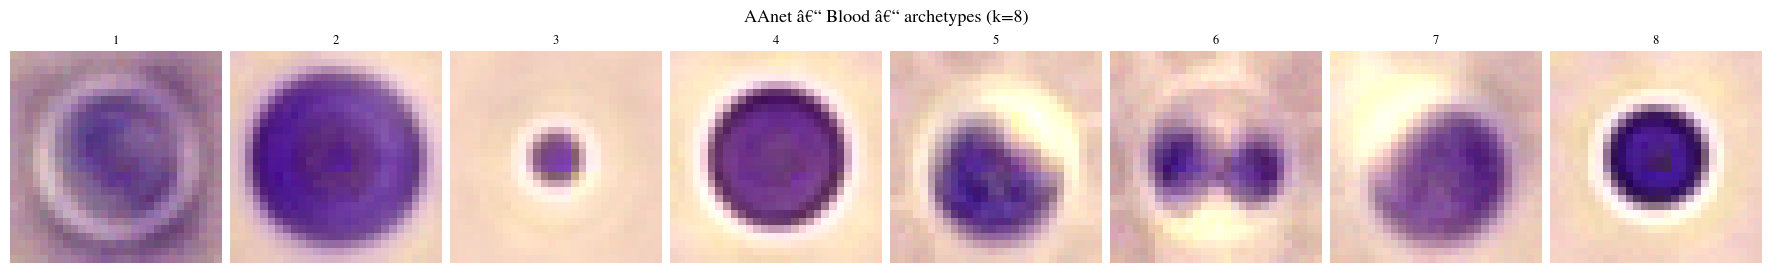

c:\DL_project\venv_aanet\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


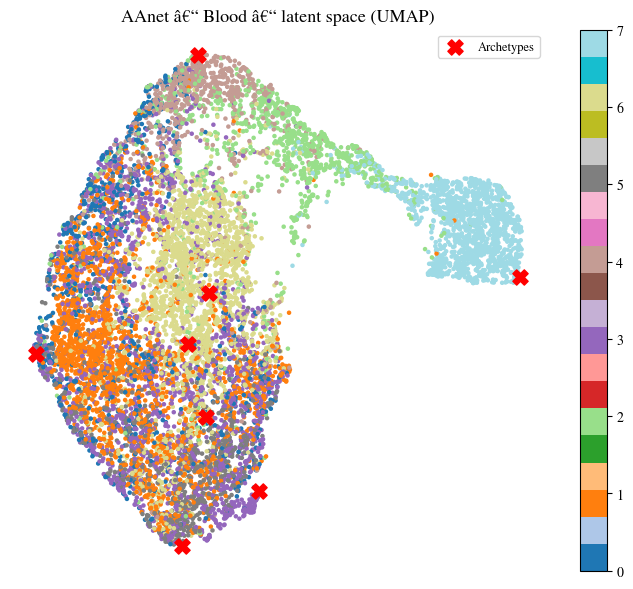

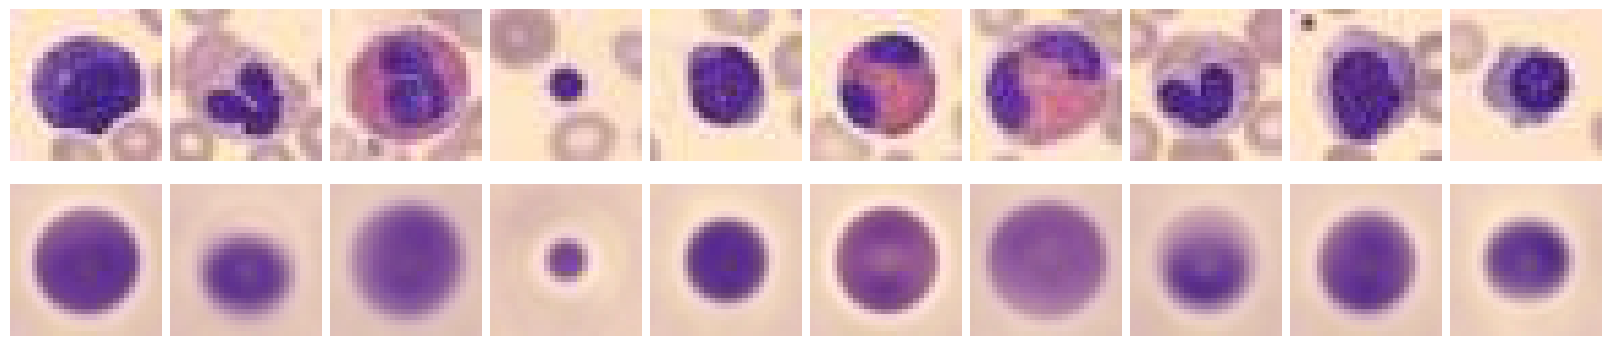

In [14]:
COLOR = colors[1]
r = r_aanet_blood
k = r['best_k']

NMI_arr = np.array(r['NMI_results'][k]).reshape(1, -1)
plot_nmi_stability(NMI_arr, [k], 'AAnet', 'Blood', [COLOR], savedir=SAVEDIR)

cm     = np.array(r['consistency_matrix'])
im_mat = np.array(r['ISI_matrix'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
sns.heatmap(cm, ax=axes[0], annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'Consistency'})
axes[0].set_title('AAnet â€“ Blood â€“ Consistency', fontsize=13)
sns.heatmap(im_mat, ax=axes[1], annot=True, fmt='.3f', cmap='Greens', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'ISI'})
axes[1].set_title('AAnet â€“ Blood â€“ ISI', fontsize=13)
plt.show()

archetypes = np.array(r['archetype_list'][0])  # (2352, k), stored in [-1,1]
fig, axes = plt.subplots(1, k, figsize=(2.2 * k, 2.8), layout='constrained')
for i in range(k):
    axes[i].imshow(np.clip((archetypes[:, i].reshape(28, 28, 3) + 1) / 2, 0, 1))
    axes[i].axis('off')
    axes[i].set_title(str(i + 1), fontsize=9)
fig.suptitle(f'AAnet â€“ Blood â€“ archetypes (k={k})', fontsize=13)
plt.show()

X_scaled                = X_blood * 2 - 1
z_all, recons, model_blood = run_aanet_inference(r, X_scaled)
arc_pts  = model_blood.archetypal_simplex.cpu().detach().numpy()
combined = np.vstack([z_all, arc_pts])
emb_all  = umap_lib.UMAP(n_components=2, random_state=42).fit_transform(combined)
emb      = emb_all[:len(z_all)]
arc_pos  = emb_all[len(z_all):]
plt.figure(figsize=(7, 6))
sc = plt.scatter(emb[:, 0], emb[:, 1], s=5, c=y_blood, cmap='tab20')
plt.colorbar(sc)
plt.scatter(arc_pos[:, 0], arc_pos[:, 1], marker='X', c='red', s=120, zorder=5, label='Archetypes')
plt.legend(fontsize=9)
plt.axis('off')
plt.title('AAnet â€“ Blood â€“ latent space (UMAP)', fontsize=13)
plt.tight_layout()
plt.show()

recons_01 = (recons + 1) / 2
n_show = 10
rng    = np.random.RandomState(42)
idx    = rng.choice(len(recons_01), n_show, replace=False)
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.6, 3.5), layout='constrained')
for j, i in enumerate(idx):
    axes[0, j].imshow(np.clip(X_blood[i].reshape(28, 28, 3), 0, 1))
    axes[1, j].imshow(np.clip(recons_01[i].reshape(28, 28, 3), 0, 1))
    axes[0, j].axis('off')
    axes[1, j].axis('off')
plt.show()


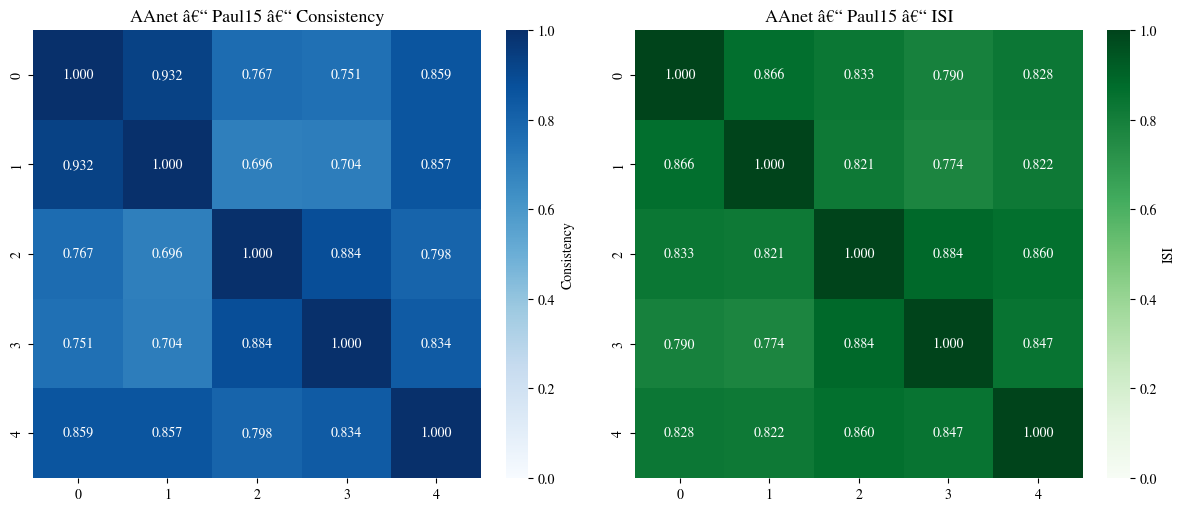

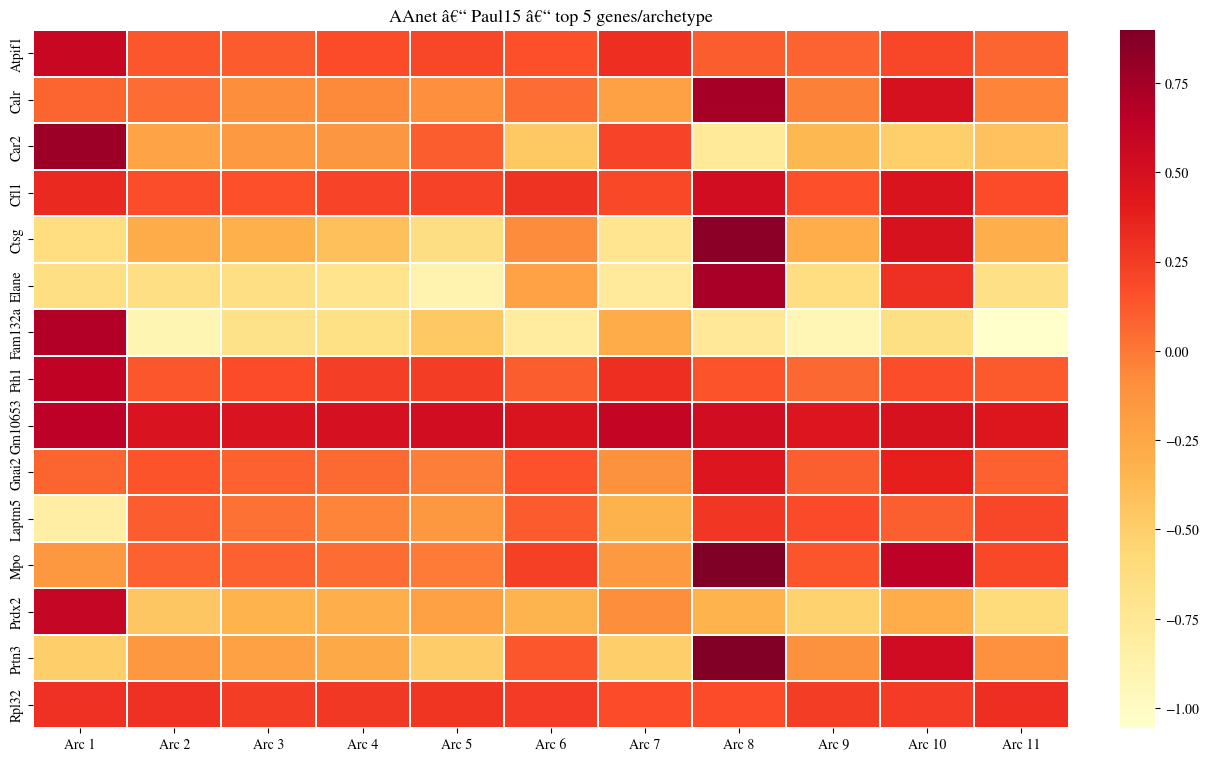

c:\DL_project\venv_aanet\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


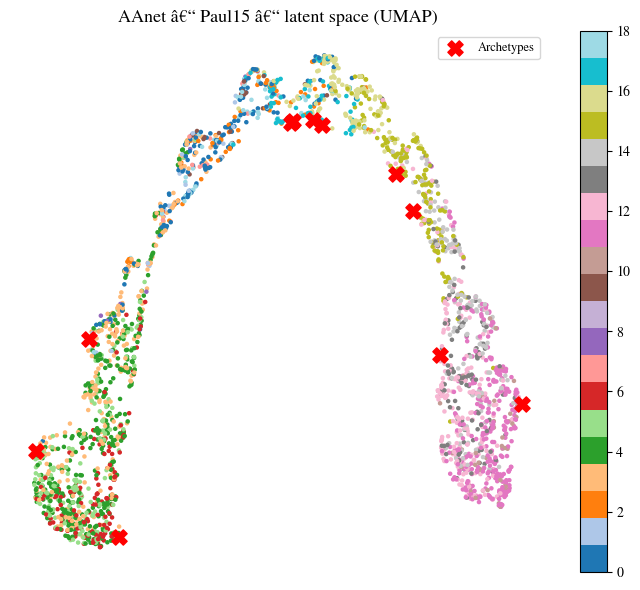

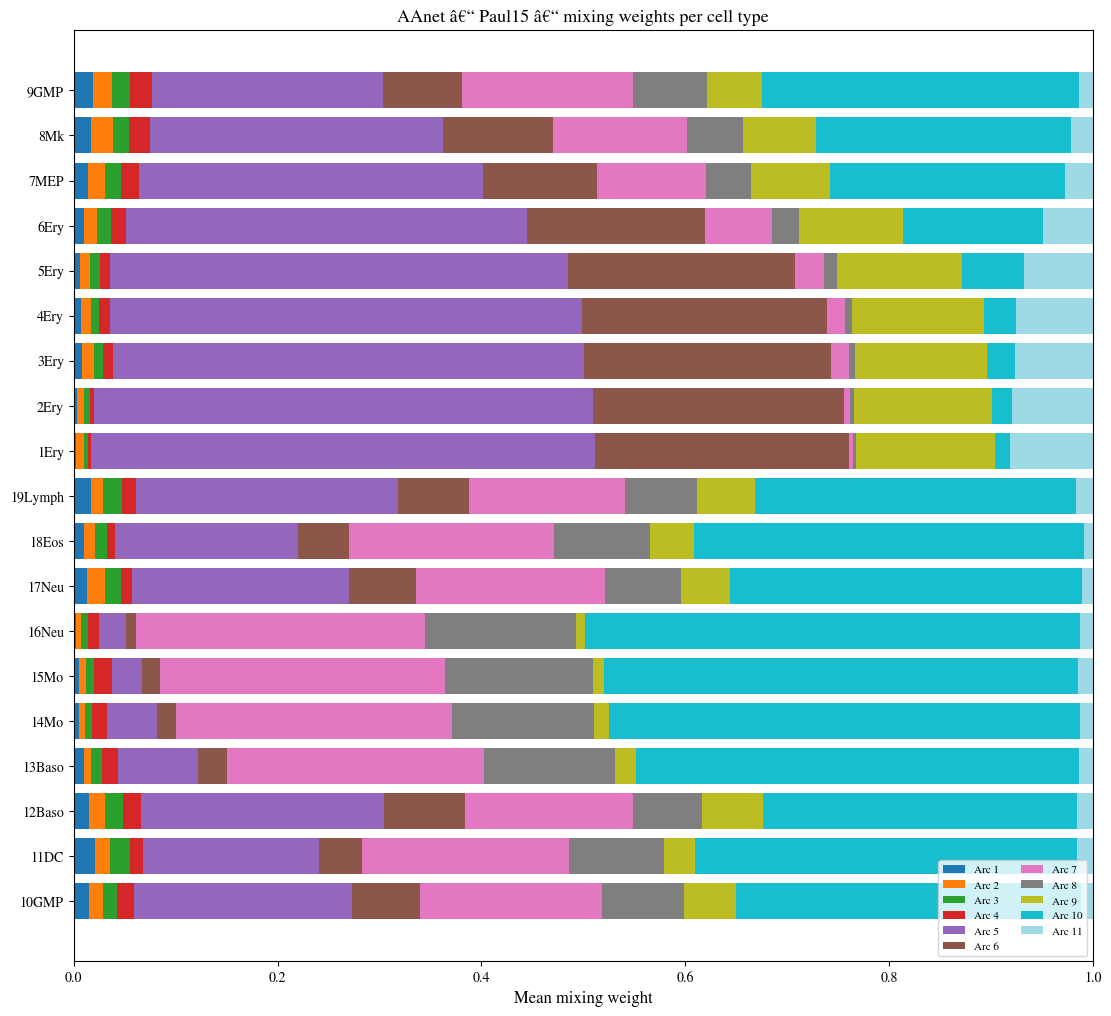

In [15]:
COLOR = colors[1]
r = r_aanet_paul15
k = r['best_k']

NMI_arr = np.array(r['NMI_results'][k]).reshape(1, -1)
plot_nmi_stability(NMI_arr, [k], 'AAnet', 'Paul15', [COLOR], savedir=SAVEDIR)

cm     = np.array(r['consistency_matrix'])
im_mat = np.array(r['ISI_matrix'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
sns.heatmap(cm, ax=axes[0], annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'Consistency'})
axes[0].set_title('AAnet â€“ Paul15 â€“ Consistency', fontsize=13)
sns.heatmap(im_mat, ax=axes[1], annot=True, fmt='.3f', cmap='Greens', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'ISI'})
axes[1].set_title('AAnet â€“ Paul15 â€“ ISI', fontsize=13)
plt.show()

archetypes = np.array(r['archetype_list'][0])  # (n_genes, k)
plot_gene_heatmap(archetypes, r['gene_names'], 'AAnet', 'Paul15', top_n=5, savedir=SAVEDIR)

X_scaled              = X_paul * 2 - 1
z_all, _, model_paul  = run_aanet_inference(r, X_scaled)
arc_pts  = model_paul.archetypal_simplex.cpu().detach().numpy()
combined = np.vstack([z_all, arc_pts])
emb_all  = umap_lib.UMAP(n_components=2, random_state=42).fit_transform(combined)
emb      = emb_all[:len(z_all)]
arc_pos  = emb_all[len(z_all):]
plt.figure(figsize=(7, 6))
sc = plt.scatter(emb[:, 0], emb[:, 1], s=5, c=y_paul, cmap='tab20')
plt.colorbar(sc)
plt.scatter(arc_pos[:, 0], arc_pos[:, 1], marker='X', c='red', s=120, zorder=5, label='Archetypes')
plt.legend(fontsize=9)
plt.axis('off')
plt.title('AAnet â€“ Paul15 â€“ latent space (UMAP)', fontsize=13)
plt.tight_layout()
plt.show()

z_t = torch.tensor(z_all).float()
with torch.no_grad():
    bary = model_paul.euclidean_to_barycentric(z_t).numpy()  # (n, k)
bary = np.clip(bary, 0, None)
bary /= bary.sum(axis=1, keepdims=True)
plot_mixing_weights(bary.T, y_paul, lnames_paul, 'AAnet', 'Paul15', SAVEDIR)


---
## Part 3 â€” MIDAA

MIDAA is a variational probabilistic model. It learns a (kâˆ’1)-dimensional latent embedding
and infers archetypes jointly with the posterior. The decoder maps latent codes back to data
space for reconstruction.

Training used `fit_MIDAA` with `steps=1000` and `lr=0.001`.

> **Virtual environment required** â€” see `requirements_midaa.txt`.

In [25]:
# MIDAA training reference (run on HPC)
#
# import midaa as maa
#
# res = maa.fit_MIDAA(
#     input_matrix=[X_dense],
#     normalization_factor=[np.ones(N)],
#     input_types=['G'],
#     loss_weights_reconstruction=[1.0],
#     lr=0.001, steps=1000, narchetypes=k, torch_seed=seed,
# )
# torch.set_default_device('cpu')  # reset after fit_MIDAA sets it globally
#
# Z = res['inferred_quantities']['Z']
# A = res['inferred_quantities']['archetypes_inferred']

r_midaa_mnist  = torch.load('results/midaa_mnist_results.pt',  map_location='cpu', weights_only=False)
r_midaa_blood  = torch.load('results/midaa_blood_results.pt',  map_location='cpu', weights_only=False)
r_midaa_paul15 = torch.load('results/midaa_paul15_results.pt', map_location='cpu', weights_only=False)

print(f'{"Dataset":10s}  {"k":>4s}  {"Consistency":>12s}  {"ISI":>8s}')
print('-' * 40)
for name, r in [('MNIST', r_midaa_mnist), ('Blood', r_midaa_blood), ('Paul15', r_midaa_paul15)]:
    k    = r['n_arc_consistency']
    R    = r['R']
    triu = np.triu_indices(R, k=1)
    cm   = np.array(r['consistency_matrix'])
    im   = np.array(r['ISI_matrix'])
    print(f'{name:10s}  {k:4d}  {cm[triu].mean():12.4f}  {im[triu].mean():8.4f}')

Dataset        k   Consistency       ISI
----------------------------------------
MNIST         10        0.7022    0.6418
Blood          8        0.6265    0.8473
Paul15        10        0.9329    0.8790


In [26]:
from MIDAA import MLPDecoder

def run_midaa_inference(result):
    dec = MLPDecoder(latent_dim=result['latent_dim'], output_dim=result['input_dim'])
    dec.load_state_dict(result['decoder_state_dict'])
    dec.eval()
    Z_t = torch.tensor(np.array(result['Z'])).float()
    with torch.no_grad():
        recons = dec(Z_t).numpy()  # (n, input_dim), output in [0,1]
    return recons

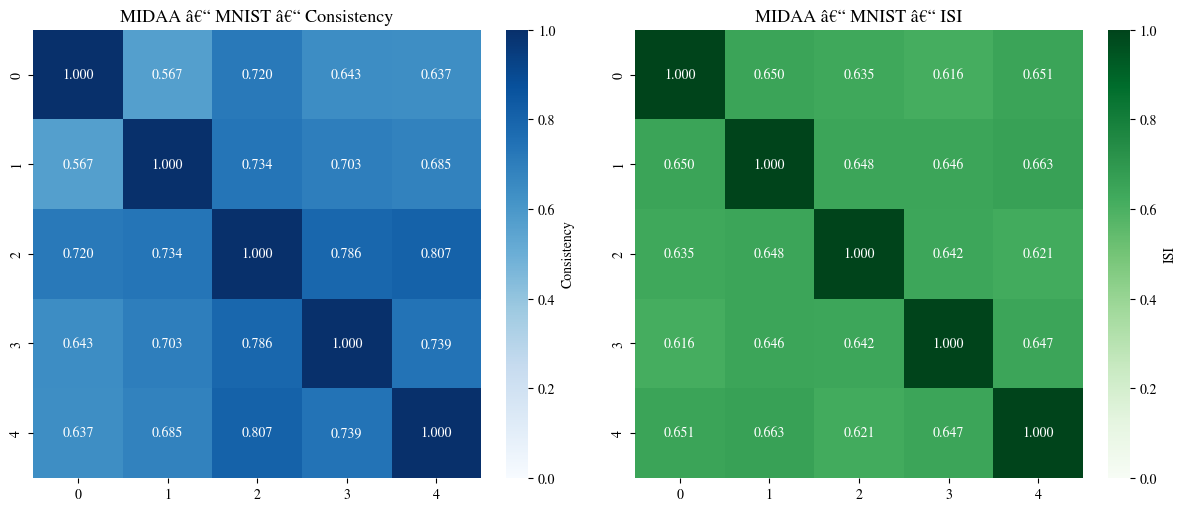

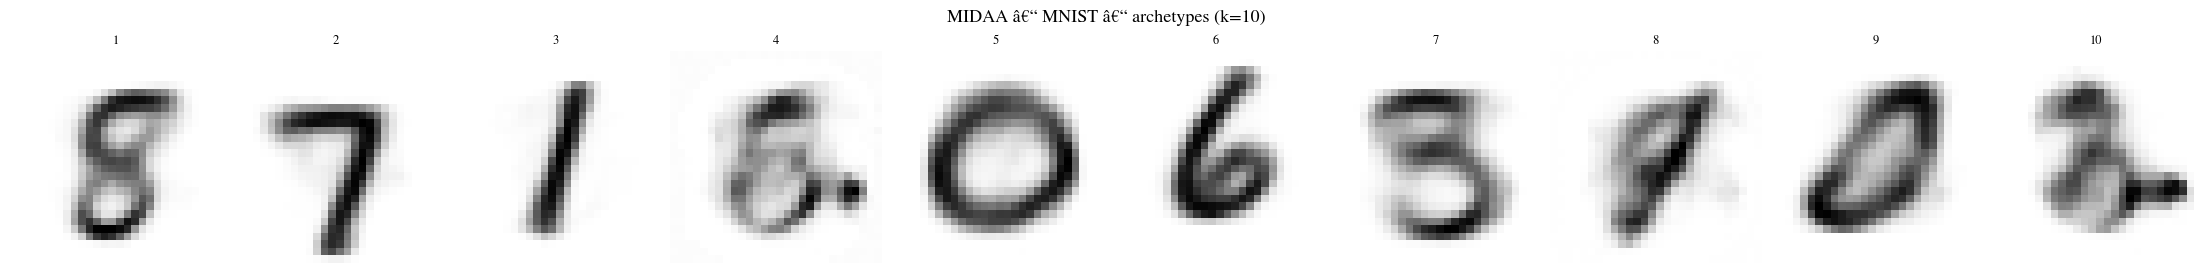

c:\DL_project\venv_midaa\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


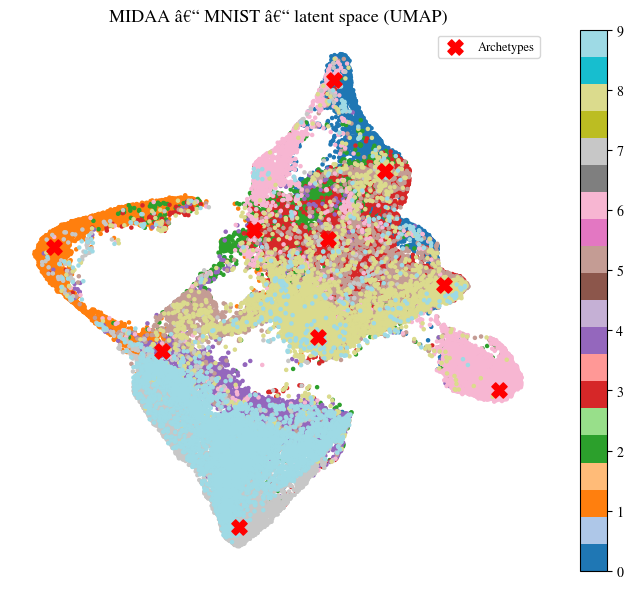

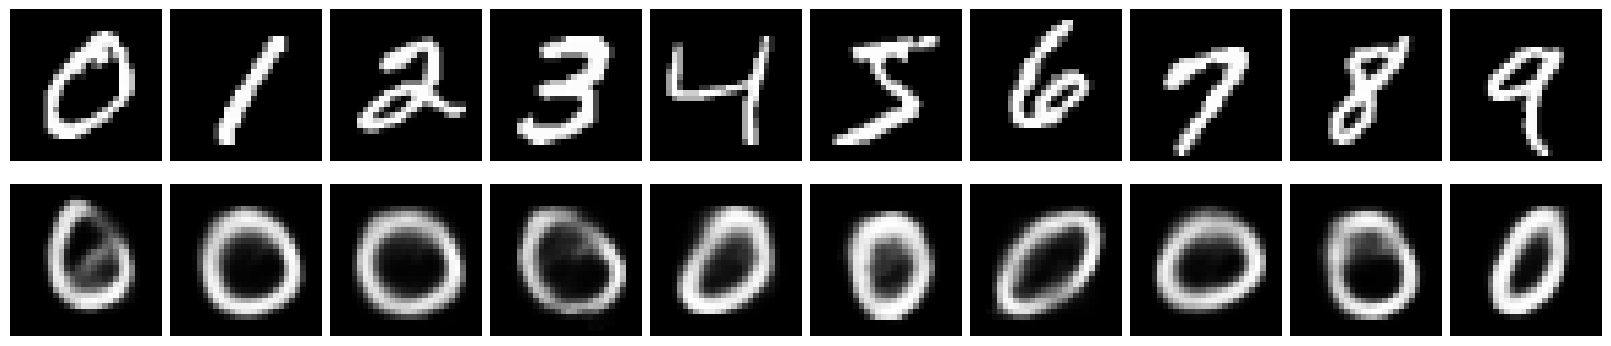

In [ ]:
COLOR = colors[4]  # blue for MIDAA
r = r_midaa_mnist
k = r['n_arc_consistency']

plot_loss_arc(np.array(r['ELBOs']), r['n_arc_list'], 3, COLOR,
              'MIDAA', 'MNIST', savedir=SAVEDIR)
plot_nmi_stability(np.array(r['NMI']), r['n_arc_list'],
                   'MIDAA', 'MNIST', [COLOR], savedir=SAVEDIR)

cm     = np.array(r['consistency_matrix'])
im_mat = np.array(r['ISI_matrix'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
sns.heatmap(cm, ax=axes[0], annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'Consistency'})
axes[0].set_title('MIDAA â€“ MNIST â€“ Consistency', fontsize=13)
sns.heatmap(im_mat, ax=axes[1], annot=True, fmt='.3f', cmap='Greens', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'ISI'})
axes[1].set_title('MIDAA â€“ MNIST â€“ ISI', fontsize=13)
plt.show()

archetypes = np.array(r['archetype_list'][0])  # (784, k)
fig, axes = plt.subplots(1, k, figsize=(2.2 * k, 2.8), layout='constrained')
for i in range(k):
    axes[i].imshow(archetypes[:, i].reshape(28, 28), cmap='gray_r')
    axes[i].axis('off')
    axes[i].set_title(str(i + 1), fontsize=9)
fig.suptitle(f'MIDAA â€“ MNIST â€“ archetypes (k={k})', fontsize=13)
plt.show()

Z      = np.array(r['Z'])
labels = np.array(r['labels'])
A_arr  = np.array(r['A'])
combined = np.vstack([Z, A_arr])
emb_all  = umap_lib.UMAP(n_components=2, random_state=42).fit_transform(combined)
emb      = emb_all[:len(Z)]
arc_pos  = emb_all[len(Z):]
plt.figure(figsize=(7, 6))
sc = plt.scatter(emb[:, 0], emb[:, 1], s=5, c=labels, cmap='tab20')
plt.colorbar(sc)
plt.scatter(arc_pos[:, 0], arc_pos[:, 1], marker='X', c='red', s=120, zorder=5, label='Archetypes')
plt.legend(fontsize=9)
plt.axis('off')
plt.title('MIDAA â€“ MNIST â€“ latent space (UMAP)', fontsize=13)
plt.tight_layout()
plt.show()



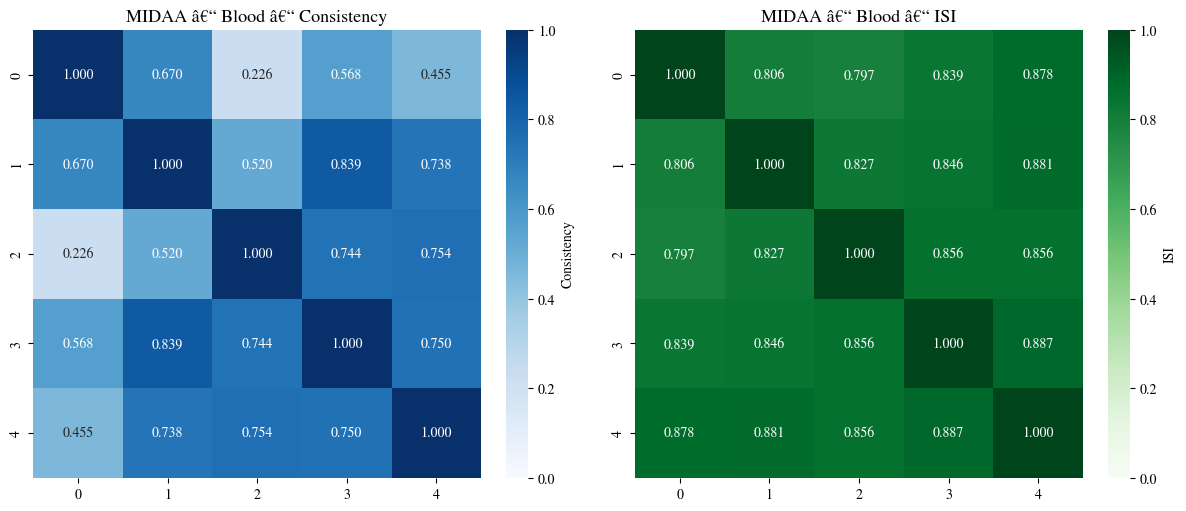

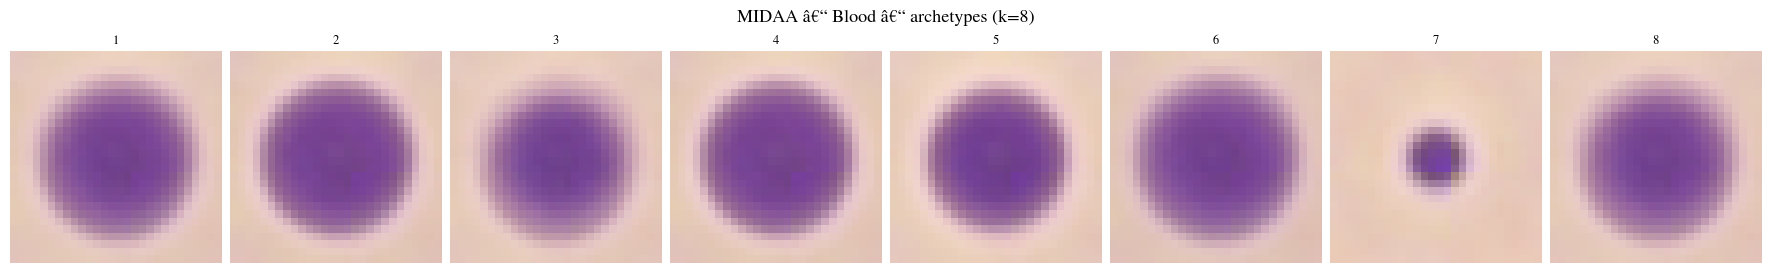

c:\DL_project\venv_midaa\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


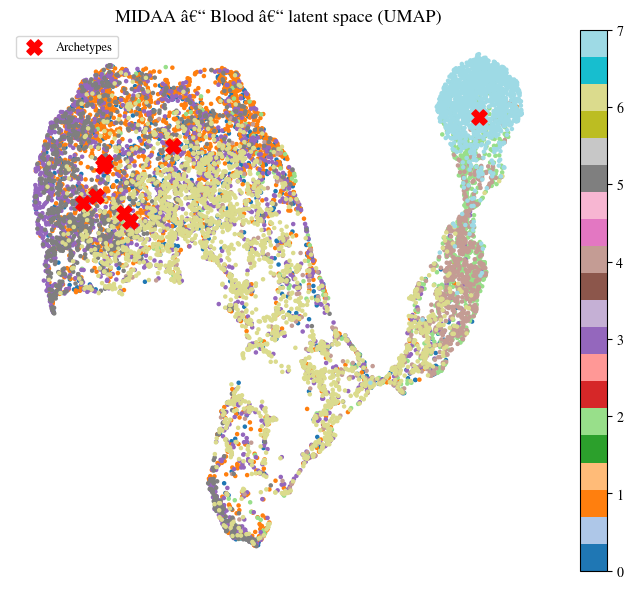

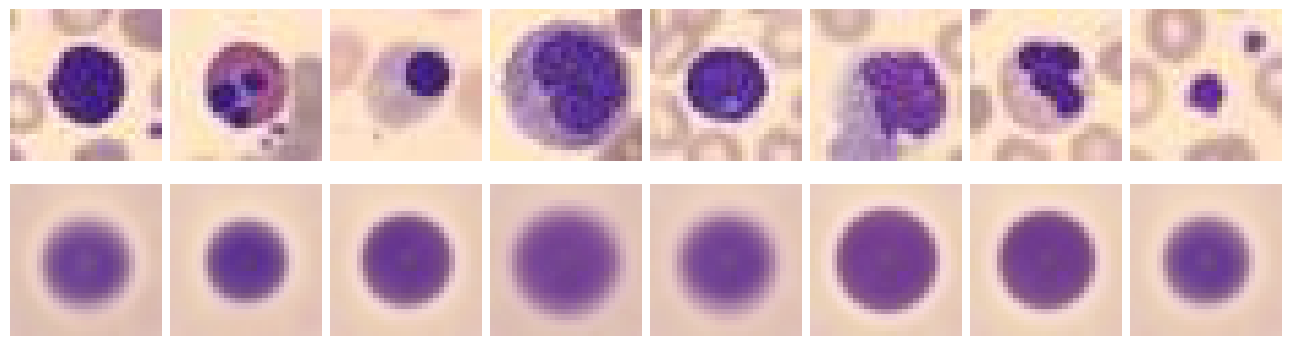

In [28]:
COLOR = colors[4]
r = r_midaa_blood
k = r['n_arc_consistency']

plot_loss_arc(np.array(r['ELBOs']), r['n_arc_list'], 4, COLOR,
              'MIDAA', 'Blood', savedir=SAVEDIR)
plot_nmi_stability(np.array(r['NMI']), r['n_arc_list'],
                   'MIDAA', 'Blood', [COLOR], savedir=SAVEDIR)

cm     = np.array(r['consistency_matrix'])
im_mat = np.array(r['ISI_matrix'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
sns.heatmap(cm, ax=axes[0], annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'Consistency'})
axes[0].set_title('MIDAA â€“ Blood â€“ Consistency', fontsize=13)
sns.heatmap(im_mat, ax=axes[1], annot=True, fmt='.3f', cmap='Greens', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'ISI'})
axes[1].set_title('MIDAA â€“ Blood â€“ ISI', fontsize=13)
plt.show()

archetypes = np.array(r['archetype_list'][0])  # (2352, k)
fig, axes = plt.subplots(1, k, figsize=(2.2 * k, 2.8), layout='constrained')
for i in range(k):
    axes[i].imshow(np.clip(archetypes[:, i].reshape(28, 28, 3), 0, 1))
    axes[i].axis('off')
    axes[i].set_title(str(i + 1), fontsize=9)
fig.suptitle(f'MIDAA â€“ Blood â€“ archetypes (k={k})', fontsize=13)
plt.show()

Z      = np.array(r['Z'])
labels = np.array(r['labels'])
A_arr  = np.array(r['A'])
combined = np.vstack([Z, A_arr])
emb_all  = umap_lib.UMAP(n_components=2, random_state=42).fit_transform(combined)
emb      = emb_all[:len(Z)]
arc_pos  = emb_all[len(Z):]
plt.figure(figsize=(7, 6))
sc = plt.scatter(emb[:, 0], emb[:, 1], s=5, c=labels, cmap='tab20')
plt.colorbar(sc)
plt.scatter(arc_pos[:, 0], arc_pos[:, 1], marker='X', c='red', s=120, zorder=5, label='Archetypes')
plt.legend(fontsize=9)
plt.axis('off')
plt.title('MIDAA â€“ Blood â€“ latent space (UMAP)', fontsize=13)
plt.tight_layout()
plt.show()

X_sub, y_use, _ = load_blood_data(subset=r['subset'])
recons  = run_midaa_inference(r)
classes = np.unique(y_use)
n_show  = len(classes)
fig, axes = plt.subplots(2, n_show, figsize=(n_show * 1.6, 3.5), layout='constrained')
for j, cls in enumerate(classes):
    idx = np.where(y_use == cls)[0][0]
    axes[0, j].imshow(np.clip(X_sub[idx].reshape(28, 28, 3), 0, 1))
    axes[1, j].imshow(np.clip(recons[idx].reshape(28, 28, 3), 0, 1))
    axes[0, j].axis('off')
    axes[1, j].axis('off')
plt.show()


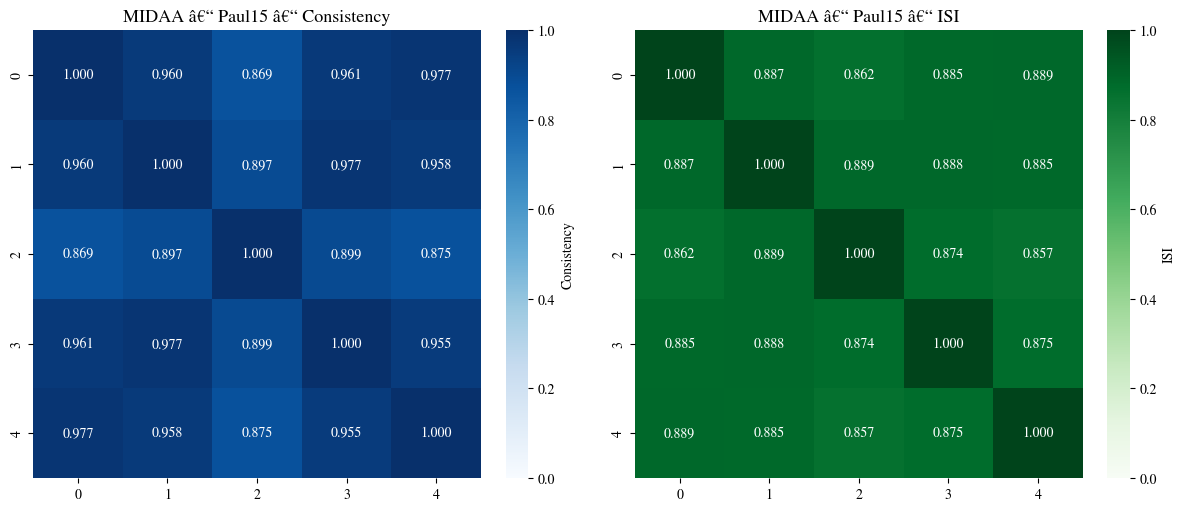

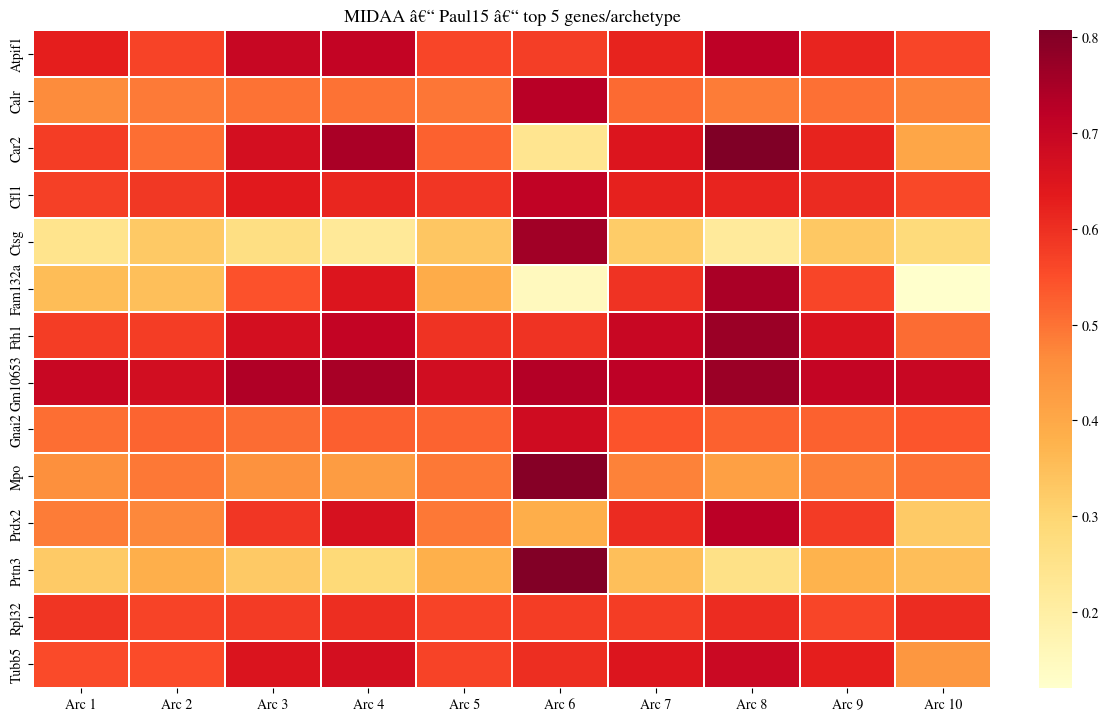

c:\DL_project\venv_midaa\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


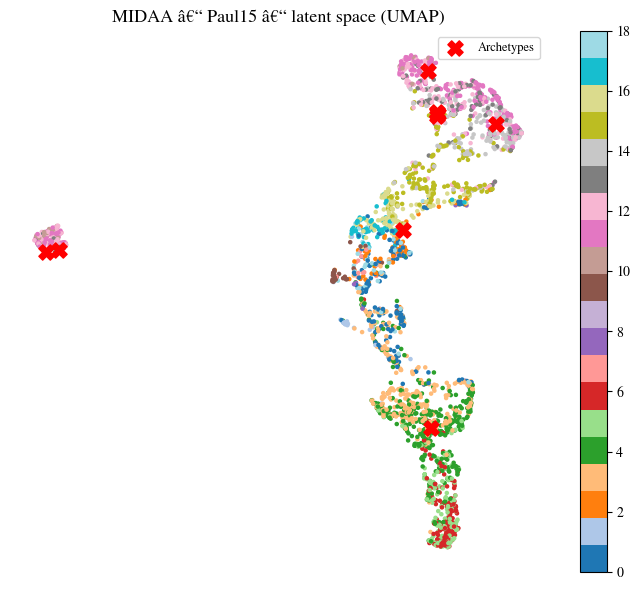

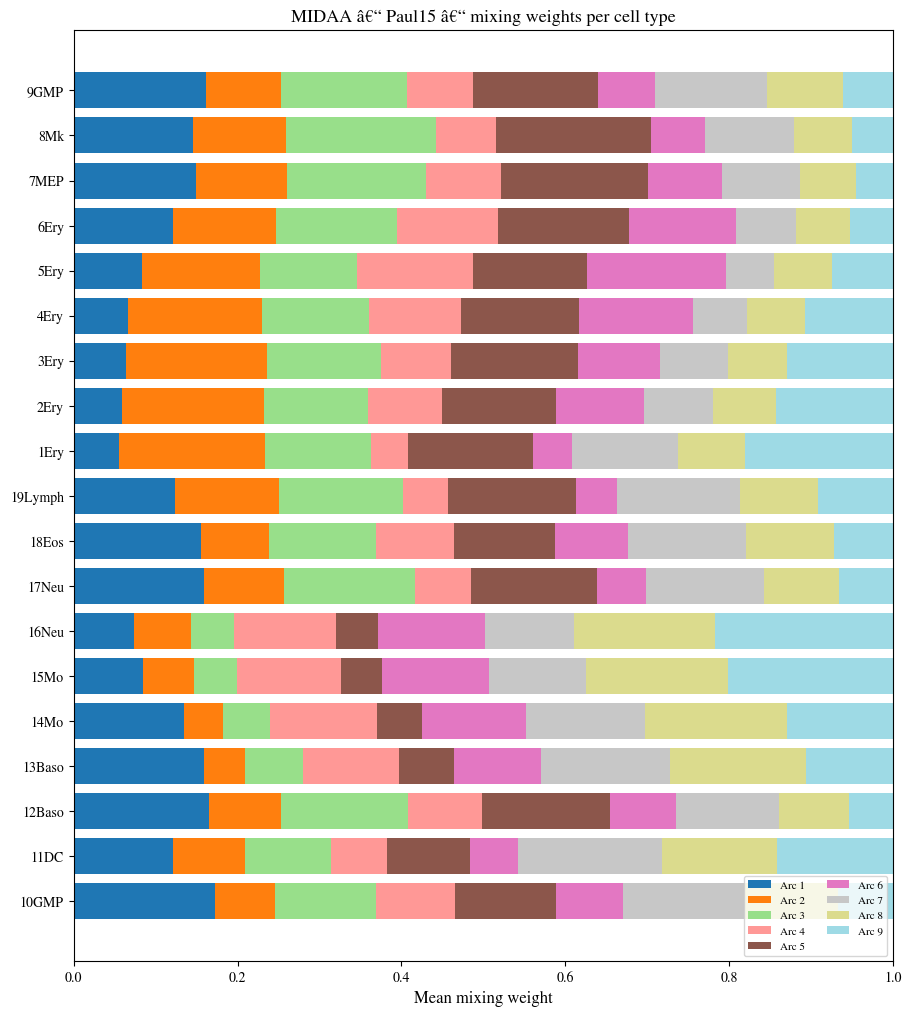

In [29]:
COLOR = colors[4]
r = r_midaa_paul15
k = r['n_arc_consistency']

plot_loss_arc(np.array(r['ELBOs']), r['n_arc_list'], 5, COLOR,
              'MIDAA', 'Paul15', savedir=SAVEDIR)
plot_nmi_stability(np.array(r['NMI']), r['n_arc_list'],
                   'MIDAA', 'Paul15', [COLOR], savedir=SAVEDIR)

cm     = np.array(r['consistency_matrix'])
im_mat = np.array(r['ISI_matrix'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout='constrained')
sns.heatmap(cm, ax=axes[0], annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'Consistency'})
axes[0].set_title('MIDAA â€“ Paul15 â€“ Consistency', fontsize=13)
sns.heatmap(im_mat, ax=axes[1], annot=True, fmt='.3f', cmap='Greens', vmin=0, vmax=1,
            square=True, cbar_kws={'label': 'ISI'})
axes[1].set_title('MIDAA â€“ Paul15 â€“ ISI', fontsize=13)
plt.show()

archetypes = np.array(r['archetype_list'][0])  # (n_genes, k)
plot_gene_heatmap(archetypes, r['gene_names'], 'MIDAA', 'Paul15', top_n=5, savedir=SAVEDIR)

Z       = np.array(r['Z'])
labels  = np.array(r['labels'])
lnames  = np.array(r['label_names'])
A_arr   = np.array(r['A'])
combined = np.vstack([Z, A_arr])
emb_all  = umap_lib.UMAP(n_components=2, random_state=42).fit_transform(combined)
emb      = emb_all[:len(Z)]
arc_pos  = emb_all[len(Z):]
plt.figure(figsize=(7, 6))
sc = plt.scatter(emb[:, 0], emb[:, 1], s=5, c=labels, cmap='tab20')
plt.colorbar(sc)
plt.scatter(arc_pos[:, 0], arc_pos[:, 1], marker='X', c='red', s=120, zorder=5, label='Archetypes')
plt.legend(fontsize=9)
plt.axis('off')
plt.title('MIDAA â€“ Paul15 â€“ latent space (UMAP)', fontsize=13)
plt.tight_layout()
plt.show()

z_shift = Z - Z.max(axis=1, keepdims=True)
exp_z   = np.exp(z_shift)
mixing  = exp_z / exp_z.sum(axis=1, keepdims=True)
plot_mixing_weights(mixing.T, labels, lnames, 'MIDAA', 'Paul15', SAVEDIR)
